In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 16
    plt.rcParams["axes.labelsize"] = 24
    plt.rcParams["legend.fontsize"] = 18

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [74]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [75]:
L_vals = [256, 512]
a_c = 0.75
a_vals = sorted([0.74, 0.75, 0.7525, 0.755, 0.7575, 0.76, 0.762])
# a_vals = [0.7525]
# a_vals = sorted([0.75])
# a_vals = sorted([0.763, 0.7675, 0.77, 0.78, 0.79])
# a_vals = [0.78, 0.79]

N_val = 4

time_prefact = 100

num_initial_conds = 1000
num_init_conds_offset = 0

time_step = 1

cmaps = {256: plt.colormaps.get_cmap("Blues").resampled(len(a_vals) + 5), 512: plt.colormaps.get_cmap("Oranges").resampled(len(a_vals) + 5)}

read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "../data"
second_data_parent_folder = "/Volumes/ExternalData/spin_dists_per_time/"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/spin_dists_per_time/"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/spin_dists_per_time/"      
        second_data_parent_folder = "../data"
else:
    data_parent_folder = local_data_parent_folder

# If first time

In [71]:


collected_sdiffs = {}
collected_sdiff_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    for a_val in a_vals:
        print(f"L_val: {L_val} | a: {a_val}")
        a_val_name = f"{a_val}".replace(".", "p")

        current_sdiff = []
        for init_cond in range(1, num_initial_conds+1):
            sample_filepath_name = os.path.join(data_parent_folder, f"N{N_val}/a{a_val_name}/IC1/L{L_val}/N{N_val}_a{a_val_name}_IC1_L{L_val}_z1p7_sample{init_cond}.csv")
                
            try:
                df = pd.read_csv(sample_filepath_name)

                current_sdiff.append(df.delta_s)
            except Exception as e:
                print(e)
                print(sample_filepath_name)
                
        current_sdiff = np.array(current_sdiff)
        collected_sdiffs[L_val][a_val] = np.mean(current_sdiff.T, axis=1)
        collected_sdiff_stds[L_val][a_val] = np.std(current_sdiff.T, axis=1)

        pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/IC{num_initial_conds}_L{L_val}_a{a_val_name}")
        # second_pickle_path = os.path.join(second_data_parent_folder, f"time_rand_binary/rho_per_time/IC{num_initial_conds}/L{L_val}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
                                                                
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_sdiffs[L_val][a_val], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_sdiff_stds[L_val][a_val], f)

        # try:
        #     dir_path = os.path.dirname(second_pickle_path)
        #     os.makedirs(dir_path, exist_ok=True)
        #     with open(second_pickle_path + "mean.pickle", "wb") as f:
        #         pickle.dump(collected_sdiffs[L_val][epsilon_prime], f)
        #     with open(second_pickle_path + "stds.pickle", "wb") as f:
        #         pickle.dump(collected_rho_stds[L_val][epsilon_prime], f)
        # except Exception as E:
        #     print(E)

L_val: 256
L_val: 256 | a: 0.74
L_val: 256 | a: 0.75
L_val: 256 | a: 0.7525
L_val: 256 | a: 0.755
L_val: 256 | a: 0.7575
L_val: 256 | a: 0.76
L_val: 256 | a: 0.762


In [ ]:
print(sample_filepath_name)

/Volumes/ExternalData/stavskya_mc/data/time_rand_binary/rho_per_time/IC1/L20000/epsilon0p2127/IC1_L20000_epsilon0p2127_timepref200_timestep10000_sample4000.csv


## If you have already processed and saved the data as pickled

In [76]:

collected_sdiffs = {}
collected_sdiff_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}
    for a_val in a_vals:
        a_val_name = f"{a_val}".replace(".", "p")
        try:
            pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/IC{num_initial_conds}_L{L_val}_a{a_val_name}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiff_stds[L_val][a_val] = pickle.load(f)

        except:
            pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/IC{num_initial_conds}_L{L_val}_a{a_val_name}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)

L_val: 256
L_val: 512


In [5]:
collected_sdiffs[L_vals[0]][a_vals[0]] == collected_sdiffs[L_vals[0]][a_vals[1]]

array([False, False, False, ..., False, False, False], shape=(40342,))

In [13]:
512**1.7

40342.1401364862

In [14]:
512*100

51200

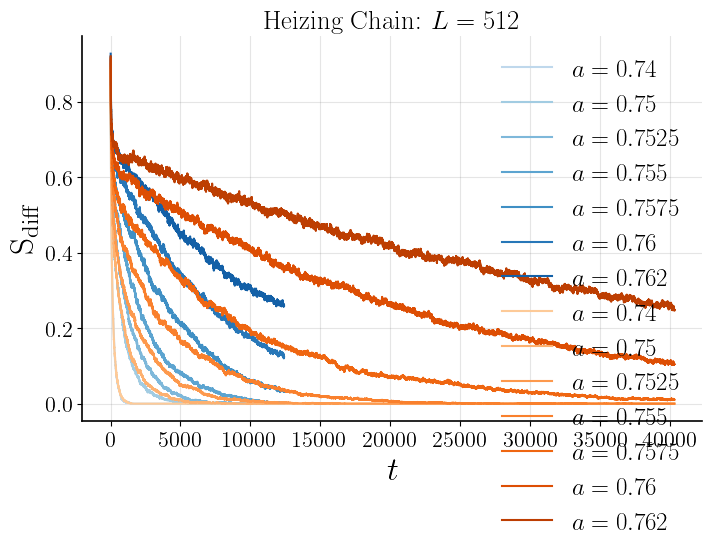

In [83]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        time_vals = [i * time_step for i in range(0, L*time_prefact // time_step)][:]
        data_to_plot = collected_sdiffs[L][a_val]
        plt.plot(
            time_vals[10:len(data_to_plot)], 
            data_to_plot[10:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"Heizing Chain: $L = {L}$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\mathrm{S_{diff}}$")
plt.legend()
# plt.ylim(0.025, 0.325)

plt.show()


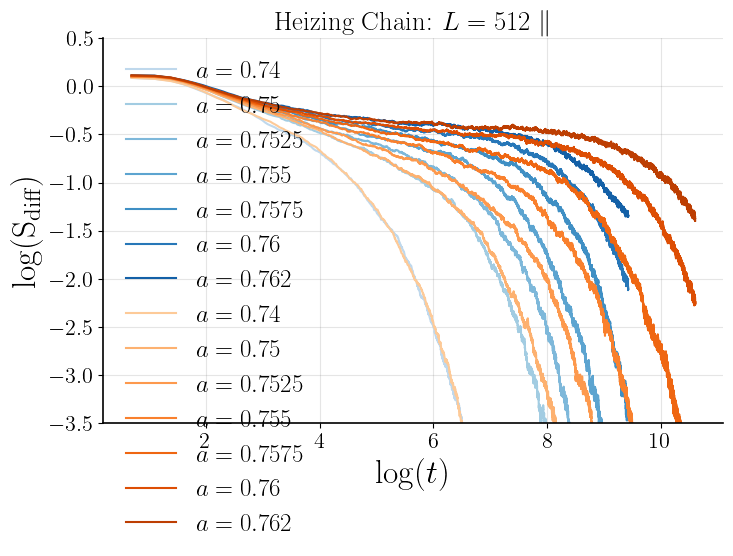

In [84]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        data_to_plot = np.log(collected_sdiffs[L][a_val])
        time_vals = [i * time_step for i in range(1, L*time_prefact // time_step)][:len(data_to_plot)]
        log_time_vals = np.log(np.array(time_vals))
        plt.plot(
            log_time_vals[1:], 
            data_to_plot[1:], 
            label = fr"$a = {round(a_val, ndigits=7)}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"Heizing Chain: $L = {L}$ $\|$")
plt.xlabel(r"$\log(t)$")
plt.ylabel(r"$\log(\mathrm{S_{diff}})$")
plt.legend()
plt.ylim(-3.5, 0.5)

plt.show()


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_55048/1611317885.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


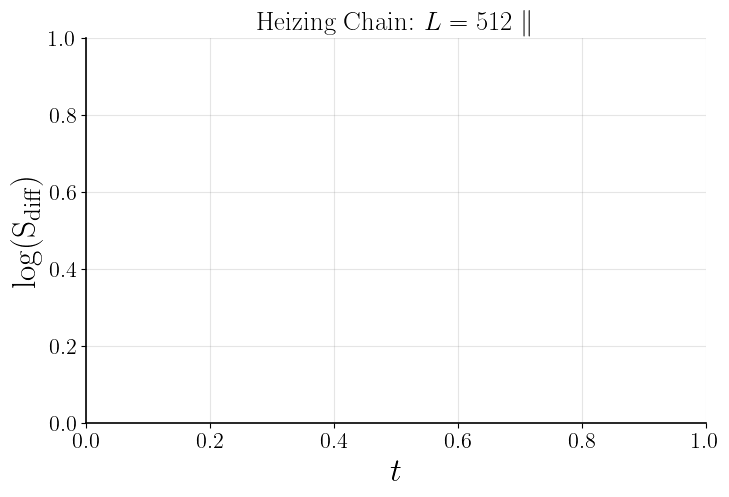

In [37]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    for i, a_val in enumerate(a_vals):
        if abs(a_val - 0.764) > 0.0002:
            continue
        c = cmap(i+3)
        data_to_plot = np.log(collected_sdiffs[L][a_val])
        time_vals = [i * time_step for i in range(1, L*time_prefact // time_step)][:len(data_to_plot)]
        log_time_vals = np.log(np.array(time_vals))
        plt.plot(
            time_vals[1:], 
            data_to_plot[1:], 
            label = fr"$a = {round(a_val, ndigits=7)}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Heizing Chain: $L = {L}$ $\|$")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$\log(\mathrm{S_{diff}})$")
    plt.legend()
    # plt.ylim(-16, 0)

    plt.show()


In [46]:
np.array(t_vals), np.array(data_to_plot), np.array(time_vals)

(array([    1,     2,     3, ..., 40338, 40339, 40340], shape=(40340,)),
 array([1.16125262, 1.11511244, 1.11318718, ..., 0.12074704, 0.12045003,
        0.1218876 ], shape=(40342,)),
 array([    10,     20,     30, ..., 403380, 403390, 403400],
       shape=(40340,)))

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_55048/2556993678.py:12: RuntimeWarning: overflow encountered in divide
  data_to_plot = log_b(data_to_plot_numerator[:len(data_to_plot_denomenator)]/data_to_plot_denomenator, 10)


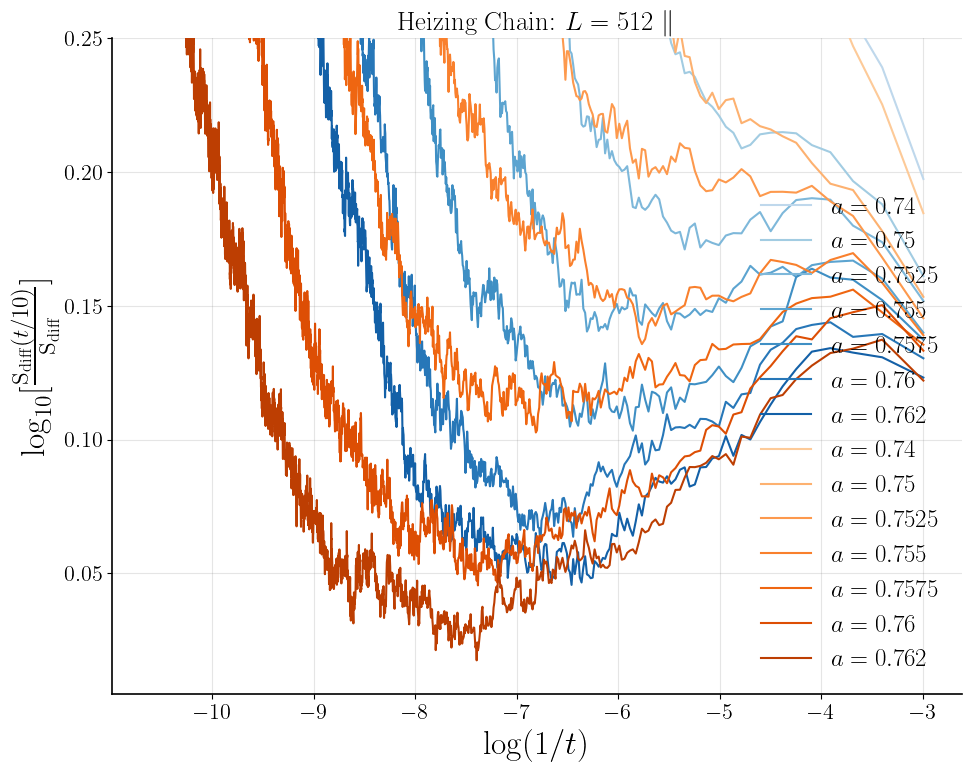

In [85]:
b = 10
delta_guess = 0.1025
plt.figure(figsize=(10,8))
for j, L in enumerate(L_vals):
    for i, a_val in enumerate(a_vals):
        c = cmaps[L](i+3)
        data_to_plot = (collected_sdiffs[L][a_val])
        t_vals = [(i+1)*time_step for i in range((len(data_to_plot)//b))]
        time_vals = [i * b*time_step for i in t_vals]
        data_to_plot_numerator = np.array([data_to_plot[(t//(b*time_step))] for t in time_vals])
        data_to_plot_denomenator = np.array([data_to_plot[t//time_step] for t in time_vals])
        data_to_plot = log_b(data_to_plot_numerator[:len(data_to_plot_denomenator)]/data_to_plot_denomenator, 10)

        plt.plot(
            np.log((1/np.array(time_vals))[1:]), 
            data_to_plot[1:], 
            label = fr"$a = {a_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    
# plt.axhline(delta_guess, c = 'k', label=fr"$\delta = {delta_guess}$", linestyle ="--")
plt.title(fr"Heizing Chain: $L = {L}$ $\|$")
plt.xlabel(r"$\log(1/t)$")
plt.ylabel(r"$\log_{10}[\frac{\mathrm{S_{diff}}(t/10)}{\mathrm{S_{diff}}}]$")
plt.legend()
# plt.xlim((np.log(0.000005), np.log(0.0005)))
plt.ylim((0.005, 0.25))
plt.tight_layout()
# plt.savefig(f"figs/time_random/a{a_val_name}/delta_estimate.png")
plt.show()

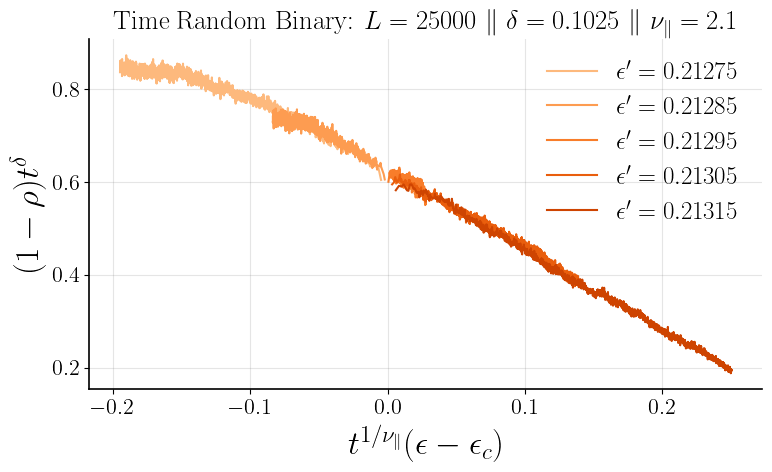

In [ ]:
delta_guess = 0.1025
guess_nu_par = 2.1
epsilon_c = 0.212925
for j, L in enumerate(L_vals):
    plt.figure(figsize=(8,5))
    for i, epsilon_val in enumerate(epsilon_prime_vals):
        if epsilon_val == epsilon_c:
            continue
        c = cmap(i+3)
        time_vals = np.array([i * time_step for i in range(0, L*100 // time_step)])
        orig_data = (1-collected_sdiffs[L][epsilon_val])[0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(epsilon_val - epsilon_c))[1:], 
            (orig_data * time_vals ** delta_guess)[1:], 
            label = fr"$\epsilon' = {epsilon_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Time Random Binary: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.xlabel(r"$t^{1/\nu_{\|}}(\epsilon - \epsilon_c)$")
    plt.ylabel(r"$(1 - \rho)t^\delta$")
    plt.legend()
    # plt.xlim(0.0003, 0.16)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    # plt.savefig(f"figs/time_random/binary/fss_nu_par.png")
    plt.show()

# By hand collpase
The expected form (near the crit pt) is

$(1-\rho)t^{\beta/\nu_{\|}} \sim g(t^{-z})$